X shape: (500, 400)
logits shape: (500,)
分类标签 y_clf shape: (500,)


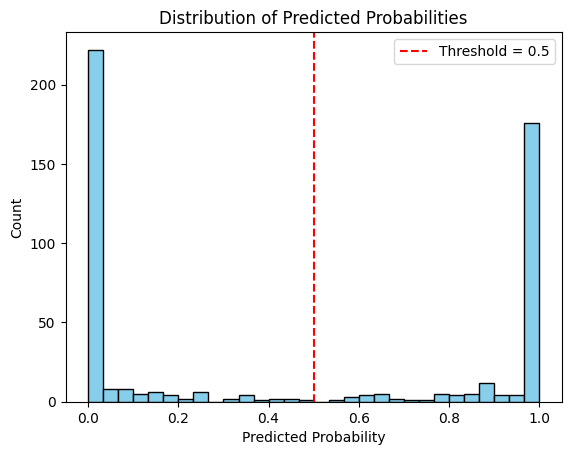

Epoch 0, Loss: 0.6966
Epoch 10, Loss: 0.5126
Epoch 20, Loss: 0.2312
Epoch 30, Loss: 0.0464
Epoch 40, Loss: 0.0076
Epoch 1/20, Loss: 0.7071, Val Loss: 0.6907
Epoch 2/20, Loss: 0.6852, Val Loss: 0.6932
Epoch 3/20, Loss: 0.6670, Val Loss: 0.6956
Epoch 4/20, Loss: 0.6510, Val Loss: 0.6980
Epoch 5/20, Loss: 0.6360, Val Loss: 0.6998
Epoch 6/20, Loss: 0.6209, Val Loss: 0.7009
Epoch 7/20, Loss: 0.6050, Val Loss: 0.7012
Epoch 8/20, Loss: 0.5879, Val Loss: 0.7010
Epoch 9/20, Loss: 0.5695, Val Loss: 0.6999
Epoch 10/20, Loss: 0.5497, Val Loss: 0.6982
Epoch 11/20, Loss: 0.5286, Val Loss: 0.6959
Epoch 12/20, Loss: 0.5061, Val Loss: 0.6932
Epoch 13/20, Loss: 0.4824, Val Loss: 0.6901
Epoch 14/20, Loss: 0.4575, Val Loss: 0.6866
Epoch 15/20, Loss: 0.4314, Val Loss: 0.6829
Epoch 16/20, Loss: 0.4044, Val Loss: 0.6792
Epoch 17/20, Loss: 0.3766, Val Loss: 0.6754
Epoch 18/20, Loss: 0.3482, Val Loss: 0.6718
Epoch 19/20, Loss: 0.3196, Val Loss: 0.6685
Epoch 20/20, Loss: 0.2909, Val Loss: 0.6656
Validation Accu

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split


n_gene = 400
n_samples = 500
X = np.random.normal(0,1,(n_samples,n_gene))

# 分类标签
X_logits = (
    X[:,50:80].sum(axis=1)*1.5 +    # 代谢模块（正相关）
    X[:,300:330].sum(axis=1)*(-2.0) # 信号通路模块（负相关）
)

# sigmoid 转概率
prob = 1 / (1 + np.exp(-X_logits))

# 二分类标签
y_clf = (prob > 0.5).astype(int)

# 打印结果检查
print("X shape:", X.shape)          # (500, 400)
print("logits shape:", X_logits.shape)  # (500,)
print("分类标签 y_clf shape:", y_clf.shape)  # (500,1)

# Step 4: 可视化标签分布
plt.hist(prob, bins=30, color='skyblue', edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities")
plt.legend()
plt.show()

# 数据准备
X_train, X_val, y_train, y_val = train_test_split(X, y_clf, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)


# 定义 MLP 分类器
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super(MLPClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),  # 输入层 → 隐藏层1
            nn.ReLU(),                  # 激活函数
            nn.Linear(128, 64),         # 隐藏层1 → 隐藏层2
            nn.ReLU(),                  # 激活函数
            nn.Linear(64, 1),           # 隐藏层2 → 输出层
            nn.Sigmoid()                # 输出概率 (0~1)
        )
    def forward(self, x):
        return self.net(x)
    



# 适合初学者的快速理解深度学习的基本流程：前向传播 → 损失 → 反向传播 → 更新
# 数据准备
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y_clf, dtype=torch.float32).reshape(-1, 1)  # 转换为列向量

# 模型、损失函数、优化器
model = MLPClassifier(input_dim=400)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练循环
for epoch in range(50):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


# 初始化模型、损失函数和优化器
model = MLPClassifier(input_dim=n_gene)
criterion = nn.BCELoss()  # 二分类交叉熵损失
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练模型
n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    # 验证模型
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
    
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# 评估模型,适合初学者理解模型性能的基本指标：准确率、精确率、召回率和F1分数
model.eval()
with torch.no_grad():
    val_outputs = model(X_val)
    predicted = (val_outputs > 0.5).float()  # 二分类阈值
    accuracy = accuracy_score(y_val, predicted)
    precision = precision_score(y_val, predicted)
    recall = recall_score(y_val, predicted)
    f1 = f1_score(y_val, predicted)
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Precision: {precision:.4f}")
print(f"Validation Recall: {recall:.4f}")
print(f"Validation F1 Score: {f1:.4f}")


# 适合跟踪每个 epoch 的指标，方便调参和分析模型收敛情况。
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

n_epochs = 20
for epoch in range(n_epochs):
    # 训练
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    # 验证
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        
        # 将概率转为标签 (0/1)
        val_pred = (val_outputs > 0.5).int()
        
        # 计算性能指标
        acc = accuracy_score(y_val.numpy(), val_pred.numpy())
        precision = precision_score(y_val.numpy(), val_pred.numpy())
        recall = recall_score(y_val.numpy(), val_pred.numpy())
        f1 = f1_score(y_val.numpy(), val_pred.numpy())
    
    print(f"Epoch {epoch+1}/{n_epochs}, "
          f"Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, "
          f"Acc: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")



In [2]:
theta = X.dot(X.T) / n_gene
y_pred = theta.dot(y_clf)
y_pred = (y_pred > 0.5).astype(int)
accuracy = (y_pred == y_clf).mean() 
print(f"基于相关性矩阵的分类准确率: {accuracy:.4f}")

基于相关性矩阵的分类准确率: 0.8340


Epoch 1/20, Train Loss: 0.6971, Val Loss: 0.7033, Acc: 0.4300, F1: 0.6014
Epoch 2/20, Train Loss: 0.6812, Val Loss: 0.6998, Acc: 0.3800, F1: 0.5441
Epoch 3/20, Train Loss: 0.6665, Val Loss: 0.6966, Acc: 0.3800, F1: 0.5156
Epoch 4/20, Train Loss: 0.6520, Val Loss: 0.6934, Acc: 0.4100, F1: 0.5280
Epoch 5/20, Train Loss: 0.6370, Val Loss: 0.6902, Acc: 0.4600, F1: 0.5424
Epoch 6/20, Train Loss: 0.6211, Val Loss: 0.6867, Acc: 0.4900, F1: 0.5321
Epoch 7/20, Train Loss: 0.6041, Val Loss: 0.6830, Acc: 0.5400, F1: 0.5577
Epoch 8/20, Train Loss: 0.5857, Val Loss: 0.6790, Acc: 0.5600, F1: 0.5600
Epoch 9/20, Train Loss: 0.5658, Val Loss: 0.6746, Acc: 0.5900, F1: 0.5773
Epoch 10/20, Train Loss: 0.5442, Val Loss: 0.6697, Acc: 0.5900, F1: 0.5684
Epoch 11/20, Train Loss: 0.5209, Val Loss: 0.6643, Acc: 0.5700, F1: 0.5376
Epoch 12/20, Train Loss: 0.4959, Val Loss: 0.6587, Acc: 0.5800, F1: 0.5435
Epoch 13/20, Train Loss: 0.4695, Val Loss: 0.6528, Acc: 0.5600, F1: 0.5111
Epoch 14/20, Train Loss: 0.4415, V

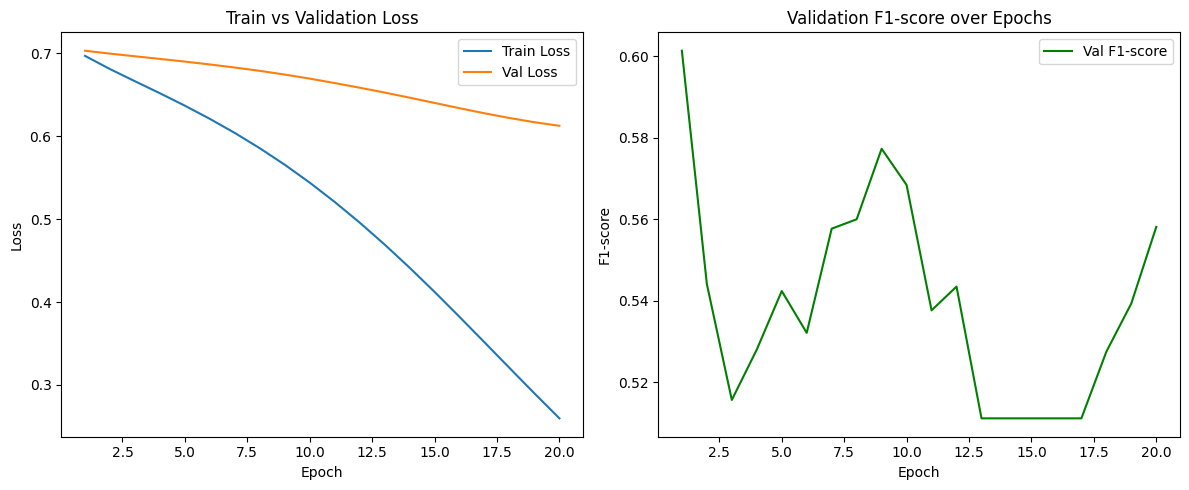

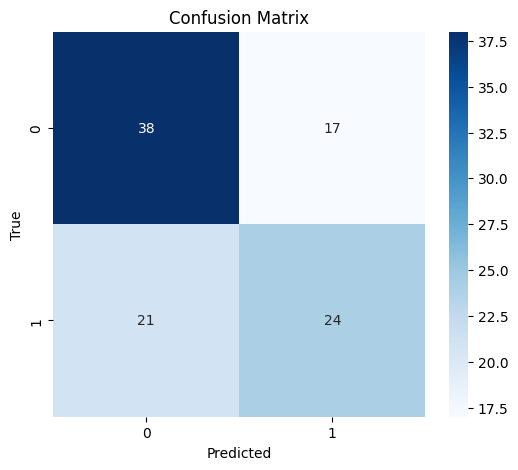

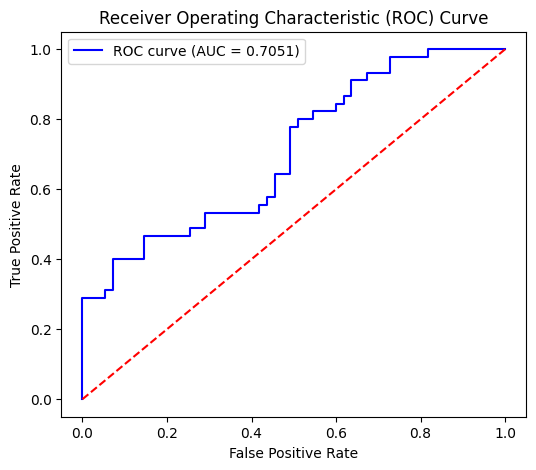

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# 数据生成
n_gene = 400
n_samples = 500
X = np.random.normal(0,1,(n_samples,n_gene))
X_logits = X[:,50:80].sum(axis=1)*1.5 + X[:,300:330].sum(axis=1)*(-2.0)
prob = 1 / (1 + np.exp(-X_logits))
y_clf = (prob > 0.5).astype(int)

# 划分训练/验证集
X_train, X_val, y_train, y_val = train_test_split(X, y_clf, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# 定义 MLP 分类器
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super(MLPClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# 初始化模型、损失函数和优化器
model = MLPClassifier(input_dim=n_gene)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 保存指标
train_losses, val_losses, val_accs, val_f1s = [], [], [], []

n_epochs = 20
for epoch in range(n_epochs):
    # 训练
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # 验证
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())
        
        val_pred = (val_outputs > 0.5).int()
        acc = accuracy_score(y_val.numpy(), val_pred.numpy())
        f1 = f1_score(y_val.numpy(), val_pred.numpy())
        val_accs.append(acc)
        val_f1s.append(f1)
    
    print(f"Epoch {epoch+1}/{n_epochs}, "
          f"Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, "
          f"Acc: {acc:.4f}, F1: {f1:.4f}")

# 绘制曲线
plt.figure(figsize=(12,5))

# 损失曲线
plt.subplot(1,2,1)
plt.plot(range(1,n_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1,n_epochs+1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()

# F1-score 曲线
plt.subplot(1,2,2)
plt.plot(range(1,n_epochs+1), val_f1s, label="Val F1-score", color="green")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Validation F1-score over Epochs")
plt.legend()

plt.tight_layout()
plt.show()


# 绘制 混淆矩阵，查看分类错误的分布
from sklearn.metrics import confusion_matrix
import seaborn as sns
model.eval()
with torch.no_grad():
    val_outputs = model(X_val)
    val_pred = (val_outputs > 0.5).int()
cm = confusion_matrix(y_val.numpy(), val_pred.numpy())
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# ROC 曲线和 AUC 分数，评估模型在不同阈值下的性能
from sklearn.metrics import roc_curve, auc
model.eval()
with torch.no_grad():
    val_outputs = model(X_val).numpy()
fpr, tpr, thresholds = roc_curve(y_val.numpy(), val_outputs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()



from sklearn.metrics import r2_score

# 标签改为连续值
y_reg = prob
X_train, X_val, y_train, y_val = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# 定义 MLP 回归器（去掉 Sigmoid）
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super(MLPRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)   # 输出连续值
        )
    def forward(self, x):
        return self.net(x)
    
# 训练函数
def train_model(loss_fn, n_epochs=20):
    model = MLPRegressor(input_dim=n_gene)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_losses, val_losses, val_r2 = [], [], []
    
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = loss_fn(outputs, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

Epoch 1/20, Train Loss: 0.3599, Val Loss: 0.3207, R²: -0.4673
Epoch 2/20, Train Loss: 0.2861, Val Loss: 0.2807, R²: -0.2841
Epoch 3/20, Train Loss: 0.2306, Val Loss: 0.2516, R²: -0.1513
Epoch 4/20, Train Loss: 0.1903, Val Loss: 0.2326, R²: -0.0643
Epoch 5/20, Train Loss: 0.1626, Val Loss: 0.2226, R²: -0.0186
Epoch 6/20, Train Loss: 0.1438, Val Loss: 0.2188, R²: -0.0011
Epoch 7/20, Train Loss: 0.1301, Val Loss: 0.2174, R²: 0.0052
Epoch 8/20, Train Loss: 0.1173, Val Loss: 0.2157, R²: 0.0130
Epoch 9/20, Train Loss: 0.1030, Val Loss: 0.2126, R²: 0.0273
Epoch 10/20, Train Loss: 0.0873, Val Loss: 0.2086, R²: 0.0457
Epoch 11/20, Train Loss: 0.0714, Val Loss: 0.2045, R²: 0.0644
Epoch 12/20, Train Loss: 0.0568, Val Loss: 0.2010, R²: 0.0805
Epoch 13/20, Train Loss: 0.0443, Val Loss: 0.1985, R²: 0.0918
Epoch 14/20, Train Loss: 0.0343, Val Loss: 0.1972, R²: 0.0979
Epoch 15/20, Train Loss: 0.0267, Val Loss: 0.1966, R²: 0.1004
Epoch 16/20, Train Loss: 0.0210, Val Loss: 0.1966, R²: 0.1005
Epoch 17/20

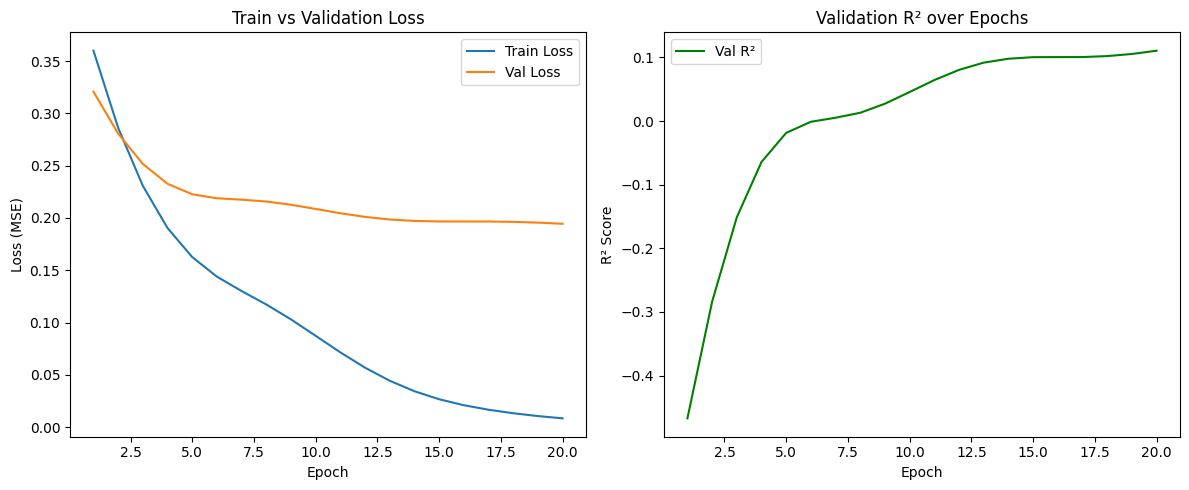

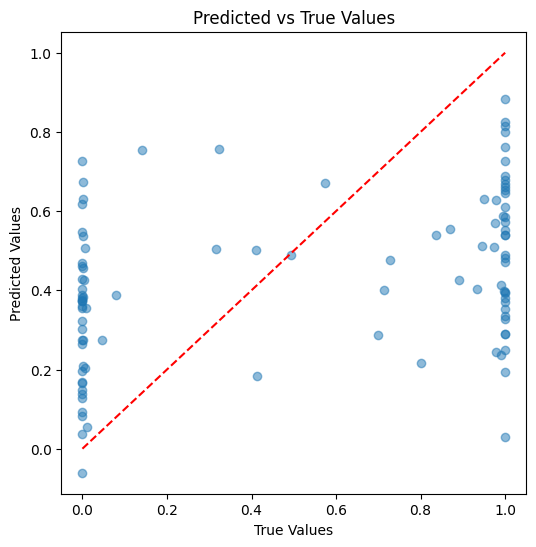

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 数据生成
n_gene = 400
n_samples = 500
X = np.random.normal(0,1,(n_samples,n_gene))
X_logits = X[:,50:80].sum(axis=1)*1.5 + X[:,300:330].sum(axis=1)*(-2.0)
prob = 1 / (1 + np.exp(-X_logits))   # 连续概率作为回归目标
y_reg = prob   # 回归标签

# 划分训练/验证集
X_train, X_val, y_train, y_val = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# 定义 MLP 回归器
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super(MLPRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)   # 输出连续值，不加 Sigmoid
        )
    def forward(self, x):
        return self.net(x)

# 初始化模型、损失函数和优化器
model = MLPRegressor(input_dim=n_gene)
criterion = nn.MSELoss()   # 回归任务常用 MSE
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 保存指标
train_losses, val_losses, val_r2 = [], [], []

n_epochs = 20
for epoch in range(n_epochs):
    # 训练
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # 验证
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())
        
        # 计算 R²
        r2 = r2_score(y_val.numpy(), val_outputs.numpy())
        val_r2.append(r2)
    
    print(f"Epoch {epoch+1}/{n_epochs}, "
          f"Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, R²: {r2:.4f}")

# 绘制曲线
plt.figure(figsize=(12,5))

# 损失曲线
plt.subplot(1,2,1)
plt.plot(range(1,n_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1,n_epochs+1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Train vs Validation Loss")
plt.legend()

# R² 曲线
plt.subplot(1,2,2)
plt.plot(range(1,n_epochs+1), val_r2, label="Val R²", color="green")
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("Validation R² over Epochs")
plt.legend()

plt.tight_layout()
plt.show()


# 绘制预测 vs 真实值的散点图，查看回归效果
model.eval()
with torch.no_grad():
    val_outputs = model(X_val).numpy()
plt.figure(figsize=(6,6))
plt.scatter(y_val.numpy(), val_outputs, alpha=0.5)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # 理想情况下的对角线
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values")
plt.show()


# 适合初学者理解回归模型的基本评估方法：均方误差（MSE）和 R² 分数。
model.eval()
with torch.no_grad():
    val_outputs = model(X_val).numpy()
mse = mean_squared_error(y_val.numpy(), val_outputs)
r2 = r2_score(y_val.numpy(), val_outputs)
print(f"Validation MSE: {mse:.4f}")
print(f"Validation R² Score: {r2:.4f}")

